# Week 4: Baseline Model

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from dateutil.relativedelta import relativedelta
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

In [122]:
df = pd.read_csv("../../data/New/df_cleaned.csv")

# Splitting Flooring and Levels by comma
df['Flooring_list'] = df['Flooring'].str.split(',')
df['Levels_list'] = df['Levels'].str.split(',')

# Drop columns that are redundant with Lat/Long
df = df.drop(columns=['Flooring', 'Levels', 'City', 'CountyOrParish', 'MLSAreaMajor', 'PostalCode', 'ListAgentAOR', 
                      'ContractStatusChangeDate', 'ListingContractDate', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListingKey'])

In [123]:
def train_test_split_by_month(df, date_col='CloseDate', n_train_months=6):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # most recent month present in the data
    max_date = df[date_col].max()
    test_month_start = max_date.replace(day=1)
    test_month_end = test_month_start + relativedelta(months=1)

    # training window: the n_train_months immediately before the test month
    train_start = test_month_start - relativedelta(months=n_train_months)
    train_end = test_month_start

    test_df = df[(df[date_col] >= test_month_start) & (df[date_col] < test_month_end)]
    train_df = df[(df[date_col] >= train_start) & (df[date_col] < train_end)]

    print(f"Test month: {test_month_start.date()} to {test_month_end.date()} ({len(test_df)} rows)")
    print(f"Train window: {train_start.date()} to {train_end.date()} ({len(train_df)} rows)")

    return train_df, test_df

In [124]:
train_df, test_df = train_test_split_by_month(df, date_col='CloseDate', n_train_months=12)

Test month: 2026-05-01 to 2026-06-01 (12017 rows)
Train window: 2025-05-01 to 2026-05-01 (129932 rows)


### More cleaning after data has been split

In [125]:
upper = train_df['ClosePrice'].quantile(0.995)
lower = train_df['ClosePrice'].quantile(0.005)
train_df = train_df[train_df['ClosePrice'].between(lower, upper)]
test_df = test_df[test_df['ClosePrice'].between(lower, upper)]

In [126]:
X_train = train_df.drop(columns=['CloseDate','ClosePrice'])
X_test = test_df.drop(columns=['CloseDate', 'ClosePrice'])

y_train = train_df['ClosePrice']
y_test = test_df['ClosePrice']

### Normalize continuous numeric features

In [127]:
continuous_cols = ['LivingArea', 'LotSizeSquareFeet', 'AssociationFee', 'GarageSpaces',
                    'ParkingTotal', 'YearBuilt', 'Latitude', 'Longitude',
                    'BedroomsTotal', 'BathroomsTotalInteger', 'Stories']
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

### Feature engineering for Linear Regression

#### Encode `Flooring_list` and `Levels_list`

#### From Claude

In [128]:
def encode_features(X_train, X_test, y_train, target_col_smoothing=10, n_splits=5, random_state=42):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # ---- 1. Flooring_list and Levels_list: multi-label binarize ----
    for col in ['Flooring_list', 'Levels_list']:
        mlb = MultiLabelBinarizer()
        train_encoded = mlb.fit_transform(X_train[col])
        test_encoded = mlb.transform(X_test[col])  # unseen labels silently ignored

        prefix = col.replace('_list', '')
        train_df = pd.DataFrame(train_encoded, columns=[f'{prefix}_{c}' for c in mlb.classes_], index=X_train.index)
        test_df = pd.DataFrame(test_encoded, columns=[f'{prefix}_{c}' for c in mlb.classes_], index=X_test.index)

        X_train = pd.concat([X_train.drop(columns=[col]), train_df], axis=1)
        X_test = pd.concat([X_test.drop(columns=[col]), test_df], axis=1)

    # ---- 2. HighSchoolDistrict: K-fold target encoding ----
    col = 'HighSchoolDistrict'
    global_mean = y_train.mean()
    train_encoded = np.zeros(len(X_train))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for tr_idx, val_idx in kf.split(X_train):
        fold_train_col = X_train[col].iloc[tr_idx]
        fold_y = y_train.iloc[tr_idx]
        fold_val_col = X_train[col].iloc[val_idx]

        stats = fold_y.groupby(fold_train_col).agg(['mean', 'count'])
        smooth_mean = (stats['mean'] * stats['count'] + global_mean * target_col_smoothing) / (stats['count'] + target_col_smoothing)
        train_encoded[val_idx] = fold_val_col.map(smooth_mean).fillna(global_mean)

    # full-training mapping, used to encode the test set
    stats_full = y_train.groupby(X_train[col]).agg(['mean', 'count'])
    smooth_mean_full = (stats_full['mean'] * stats_full['count'] + global_mean * target_col_smoothing) / (stats_full['count'] + target_col_smoothing)
    test_encoded = X_test[col].map(smooth_mean_full).fillna(global_mean)

    X_train[f'{col}_target_enc'] = train_encoded
    X_test[f'{col}_target_enc'] = test_encoded
    X_train = X_train.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

    return X_train, X_test


# usage
X_train, X_test = encode_features(X_train, X_test, y_train)

In [129]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128642 entries, 256909 to 386840
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ViewYN                         128642 non-null  int64  
 1   PoolPrivateYN                  128642 non-null  int64  
 2   Latitude                       128642 non-null  float64
 3   Longitude                      128642 non-null  float64
 4   LivingArea                     128642 non-null  float64
 5   AttachedGarageYN               128642 non-null  int64  
 6   ParkingTotal                   128642 non-null  float64
 7   YearBuilt                      128642 non-null  float64
 8   BathroomsTotalInteger          128642 non-null  float64
 9   BedroomsTotal                  128642 non-null  float64
 10  FireplaceYN                    128642 non-null  int64  
 11  Stories                        128642 non-null  float64
 12  NewConstructionYN             

## Linear Regression

#### Normal

In [175]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 5. Extract model parameters
print(f"Coefficiens: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

# 6. Evaluate model performance
rmse_dollars = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Coefficiens: [ 4.75315431e+04 -1.36494106e+05 -4.93018943e+04 -2.95506930e+04
  4.82534560e+05  2.02548761e+03 -1.30606396e+04 -1.34780266e+05
  2.11436737e+05 -7.24565092e+04  3.81099356e+04  4.09856786e+04
  9.56557741e+04 -3.07674946e+04  2.38570580e+04  1.13755962e+03
 -1.94614031e+04  2.12741582e+05 -1.32361571e+05 -2.87614379e+03
 -8.11091927e+04 -4.41523481e+04  1.73914537e+05 -3.61319121e+04
 -4.26278098e+04 -3.17347539e+04  1.94129690e+05  4.29072600e+04
  3.09545655e+04  1.26942278e+04 -2.16476081e+05  8.75140817e+04
  7.24201868e-01]
Intercept: 365267.1978
Root Mean Squared Error (RMSE): 586746.7400
R-squared (R²) Score: 0.6594


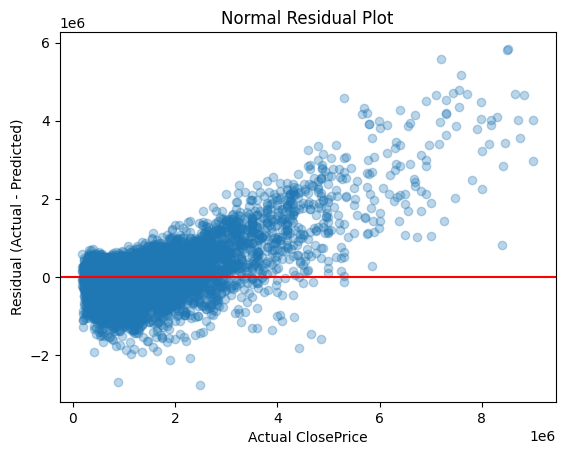

In [177]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Actual ClosePrice')
plt.ylabel('Residual (Actual - Predicted)')
plt.title("Normal Residual Plot")
plt.show()

In [174]:
model_log = LinearRegression()

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log.fit(X_train, y_train_log)

y_pred_log = model_log.predict(X_test)
y_pred_dollars = np.expm1(y_pred_log)

# 5. Extract model parameters
print(f"Coefficiens: {model_log.coef_}")
print(f"Intercept: {model_log.intercept_:.4f}")

# 6. Evaluate model performance
rmse_dollars = np.sqrt(mean_squared_error(y_test, y_pred_dollars))
r2 = r2_score(y_test, y_pred_dollars)
print(f"Root Mean Squared Error (RMSE): {rmse_dollars:.4f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Coefficiens: [-1.19545218e-02 -5.08214466e-02 -9.25084146e-02 -4.33900163e-02
  2.35024022e-01  1.23035300e-02 -2.86824739e-03 -1.04234465e-01
  1.12418039e-01  1.02129819e-02  7.60255226e-02  8.17840402e-03
  3.27469181e-02  1.42584802e-02 -1.67708659e-03 -5.61740412e-04
  5.53027440e-02  6.80721778e-02 -8.35211687e-02 -1.17990771e-02
 -4.83764278e-02 -3.75958516e-03  7.22237754e-02  6.64027931e-03
 -2.86483803e-02 -2.05856390e-03  1.63939878e-01  5.30124448e-02
 -3.60837867e-02 -8.45830279e-03 -7.71925862e-02  6.49197245e-02
  5.65286585e-07]
Intercept: 13.0828
Root Mean Squared Error (RMSE): 739778.4317
R-squared (R²) Score: 0.4586


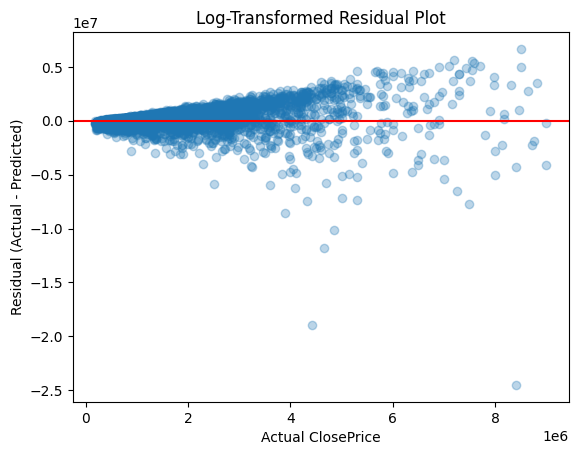

In [178]:
residuals = y_test - y_pred_dollars  # or y_pred if not log-transforming
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Actual ClosePrice')
plt.ylabel('Residual (Actual - Predicted)')
plt.title("Log-Transformed Residual Plot")
plt.show()